### Imports and basic preprocessing over data and also mlflow connect:

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score,roc_auc_score
import missingno as ms
from feature_engine.imputation import RandomSampleImputer
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
import optuna
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import ExtraTreesRegressor
import mlflow
import dagshub
import mlflow.sklearn
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
import os
import pickle

D:\Andacoda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\Andacoda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [16]:
mlflow.set_tracking_uri("https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow")

dagshub.init(repo_owner='PriyanshuMewal', repo_name='delivery-time-prediction', mlflow=True)

mlflow.set_experiment("delivery time prediction baseline experiment using Random Forest")

Accessing as PriyanshuMewal

Initialized MLflow to track repo "PriyanshuMewal/delivery-time-prediction"

Repository PriyanshuMewal/delivery-time-prediction initialized!

<Experiment: artifact_location='mlflow-artifacts:/b7da7760887d468bb808fa8df35ee318', creation_time=1771083547161, experiment_id='1', last_update_time=1771083547161, lifecycle_stage='active', name='delivery time prediction baseline experiment using Random Forest', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [2]:
from sklearn import set_config
set_config(transform_output="pandas")

In [31]:
df = pd.read_csv("../data/interim/India-Food-Delivery-Time-Prediction_cleaned.csv")
df.head()

,city,age,ratings,rest_lat,rest_long,delivery_lat,delivery_long,date,weather,traffic,condition,order_type,vehicle_type,multi_deliveries,festival,city_type,time,order_day,order_month,order_day_of_week,is_weekend,order_time_hour,order_time_of_day,pickup_time,distance,distance_type
0,indo,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,2,snack,motorcycle,0.0,no,urban,24.0,19,3,saturday,1,11.0,morning,11.933333,3.025149,short
1,bang,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33.0,25,3,friday,0,19.0,evening,6.200000,20.183530,very_long
2,bang,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26.0,19,3,saturday,1,8.0,morning,15.816667,1.552758,short
3,coimb,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21.0,5,4,tuesday,0,18.0,evening,8.900000,7.790401,medium
4,chen,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30.0,26,3,saturday,1,13.0,afternoon,11.333333,6.210138,medium


In [15]:
train_df = pd.read_csv("../data/interim/train_cleaned.csv")
test_df = pd.read_csv("../data/interim/test_cleaned.csv")

In [19]:
pd.set_option("display.max_columns", None)

In [32]:
df = df[df.isna().sum(axis=1) <= 7]
df.shape

(41840, 26)

In [33]:
cols_to_drop = ["rest_lat", "rest_long", 
                "delivery_lat", "delivery_long", 
                "date", "order_time_hour", 
                "order_day", "city", 
                "order_day_of_week"]

df.drop(columns=cols_to_drop, inplace=True)

### Experiment 1: Random forest and Gradient Boosting with no missing values:

In [34]:
df_copy = df.copy()

In [36]:
df_copy.dropna(inplace=True)

In [37]:
X = df_copy.drop(columns=["time"])
y = df_copy["time"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(29532, 16) (7383, 16) (29532,) (7383,)


In [39]:
y_train

2788     17.0
36411    28.0
32533    41.0
29327    21.0
40988    21.0
         ... 
30675    31.0
35819    25.0
23095    28.0
1057     37.0
39446    19.0
Name: time, Length: 29532, dtype: float64

In [11]:
nom_cat = ["weather", "order_type", "vehicle_type", "festival", "city_type"]

ord_cat = ["traffic", "distance_type", "order_time_of_day"]

numerical = ["age", "ratings", "pickup_time", "distance"]

In [12]:
traffic_categories = ['low', 'medium', 'high', 'jam']
distance_type_categories = ['short', 'medium', 'long', 'very_long']
time_categories = ['morning', 'afternoon', "evening", 'night']

In [13]:
col_trf = ColumnTransformer(transformers=[
    ("ord_cat", OrdinalEncoder(categories=[traffic_categories, distance_type_categories, time_categories]), ord_cat),
    ("nom_cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nom_cat),
    ("num", MinMaxScaler(), numerical)
], remainder="passthrough", n_jobs=-1)

col_trf.set_output(transform="pandas")

,transformers,"[('ord_cat', ...), ('nom_cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,"[['low', 'medium', ...], ['short', 'medium', ...], ...]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [14]:
scaler = StandardScaler()

y_train_scaled = pd.Series(scaler.fit_transform(y_train.values.reshape(y_train.shape[0], 1)).values.ravel(), 
                           index=y_train.index, name=y_train.name)
y_test_scaled = pd.Series(scaler.transform(y_test.values.reshape(y_test.shape[0], 1)).values.ravel(), 
                           index=y_test.index, name=y_test.name)

In [16]:
X_train_trf = col_trf.fit_transform(X_train)
X_test_trf = col_trf.transform(X_test)

X_train_trf["time"] = y_train_scaled
X_test_trf["time"] = y_test_scaled

X_train_trf.shape, X_test_trf.shape

((29532, 25), (7383, 25))

In [17]:
X_train_trf.to_csv("../data/processed/without_missing_values/train_df.csv", index=False)
X_test_trf.to_csv("../data/processed/without_missing_values/test_df.csv", index=False)

with open("../data/processed/without_missing_values/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [16]:
models = [RandomForestRegressor(), GradientBoostingRegressor()]

for model in models:

    pipline = Pipeline(steps=[
    ("preprocess", col_trf),
    ("model_train", model)
    ])

    pipline.fit(X_train, y_train)

    y_pred = pipline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    scores = cross_validate(pipline, X_train, y_train, cv=5, scoring=["neg_mean_absolute_error", "r2"])

    neg_mean_absolute_error = scores["test_neg_mean_absolute_error"].mean()
    mean_r2_score = scores["test_r2"].mean()    
    
    with mlflow.start_run(run_name=f"missing values droped with {model.__class__.__name__}"):
        
        parameters = {
            "test_size": 0.2,
            'imputers': "drop_na",
            "encoders": "[ordinal, onehot]",
            "sacler": "min_max_scaler",
            "model": model.__class__.__name__
        }
    
        # logging parameters:
        mlflow.log_params(parameters)
        
        # logging metrics:
        mlflow.log_metric("mean_absolute_error", mae)
        mlflow.log_metric("r2_score", r2)
        mlflow.log_metric("neg_mean_absolute_error", neg_mean_absolute_error)
        mlflow.log_metric("mean_r2_score", mean_r2_score)
        
        # logging model:
        # signature = mlflow.models.infer_signature(X_test, y_pred)
        # mlflow.sklearn.log_model(pipline, name=f"{model.__class__.__name__}", signature=signature)
    
        
        # logging datasets:
        # mlflow.log_artifact("../data/interim/India-Food-Delivery-Time-Prediction_cleaned.csv")
        
        # Set tags:
        # mlflow.set_tag("Author", "Priyanshu Mewal")
        # mlflow.set_tag("Description", "Food delivery prediction with no missing values using random forest.")
        # mlflow.set_tag("Experiment", "Baseline Experiment")

🏃 View run missing values droped with RandomForestRegressor at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1/runs/58be1ce652a64c83a1ff1800495c6943
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1
🏃 View run missing values droped with GradientBoostingRegressor at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1/runs/2560d05191f446218b17c120a122fd99
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1


### Analysis to fill missing values

In [14]:
X_train.shape

(33470, 16)

In [11]:
(X_train.isnull().sum()/ X_train.shape[0])*100

age                  4.161567
ratings              4.269039
weather              1.212049
traffic              1.173239
condition            0.000000
order_type           0.000000
vehicle_type         0.000000
multi_deliveries     2.149446
festival             0.537362
city_type            2.656954
order_month          0.000000
is_weekend           0.000000
order_time_of_day    4.755650
pickup_time          5.621399
distance             0.000000
distance_type        0.000000
dtype: float64

In [12]:
(X_train.isna().any(axis=1).sum() / X_train.shape[0])*100

11.893602412156312

<Axes: >

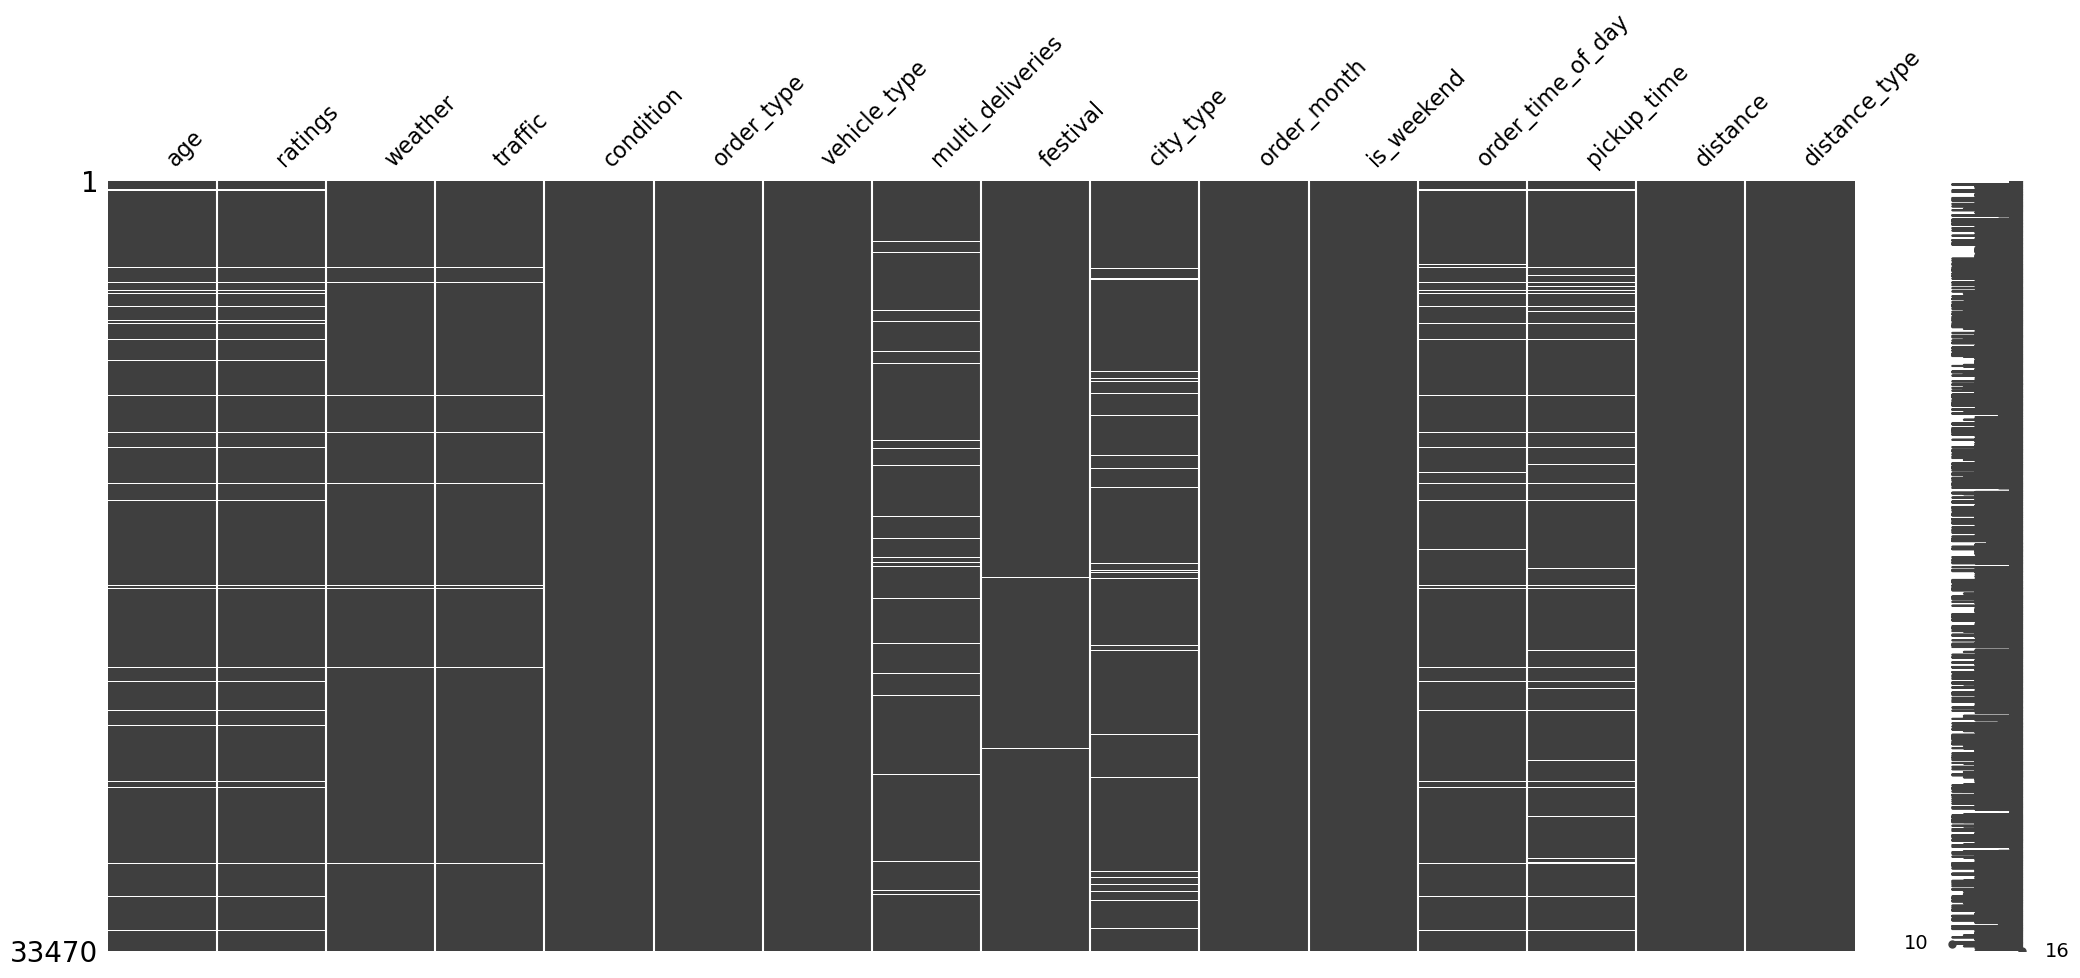

In [15]:
ms.matrix(X_train)

In [54]:
missing_cols = X_train.isnull().any(axis=0).loc[lambda x: x].index

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multi_deliveries', 'festival',
       'city_type', 'order_time_of_day', 'pickup_time'],
      dtype='str')

In [17]:
X_train["age"].describe()

count    32103.00000
mean        29.55459
std          5.75720
min         20.00000
25%         25.00000
50%         30.00000
75%         35.00000
max         39.00000
Name: age, dtype: float64

<Axes: ylabel='Density'>

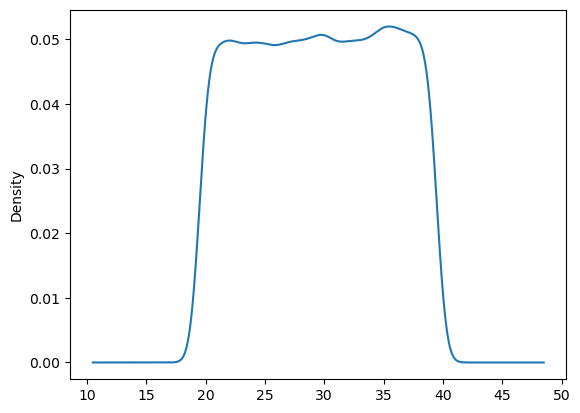

In [55]:
X_train["age"].plot(kind="kde")

In [56]:
age_mean = X_train["age"].fillna(df["age"].mean())
age_median = X_train["age"].fillna(df["age"].median())

In [57]:
X_train["age"].var(), age_mean.var(), age_median.var()

(33.145351728123295, 31.79157089573994, 31.799342795824877)

<Axes: ylabel='Density'>

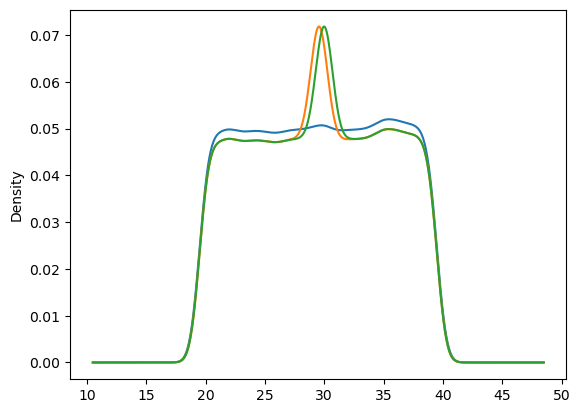

In [58]:
X_train["age"].plot(kind="kde")
age_mean.plot(kind="kde")
age_median.plot(kind="kde")

In [59]:
X_train["ratings"].describe()

count    32067.000000
mean         4.633021
std          0.315218
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

In [60]:
ratings_mean = X_train["ratings"].fillna(df["ratings"].mean())
ratings_median = X_train["ratings"].fillna(df["ratings"].median())

<Axes: ylabel='Density'>

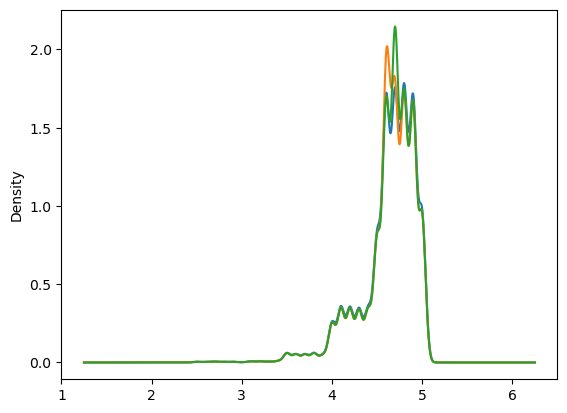

In [61]:
X_train["ratings"].plot(kind="kde")
ratings_mean.plot(kind="kde")
ratings_median.plot(kind="kde")

In [62]:
X_train["ratings"].var(), ratings_mean.var(), ratings_median.var()

(0.09936267536318735, 0.09519749028262814, 0.09537762533855006)

In [63]:
X_train["weather"].value_counts()

weather
fog           5585
sandstorms    5573
stormy        5526
cloudy        5518
windy         5500
sunny         5389
Name: count, dtype: int64

In [64]:
X_train["weather"].isnull().sum()

379

In [65]:
X_train["traffic"].value_counts()

traffic
low       11327
jam       10471
medium     8060
high       3246
Name: count, dtype: int64

In [66]:
X_train["traffic"].isnull().sum()

366

In [30]:
imputer = RandomSampleImputer(random_state=42, variables=["traffic"])
X_train_trf = imputer.fit_transform(X_train)

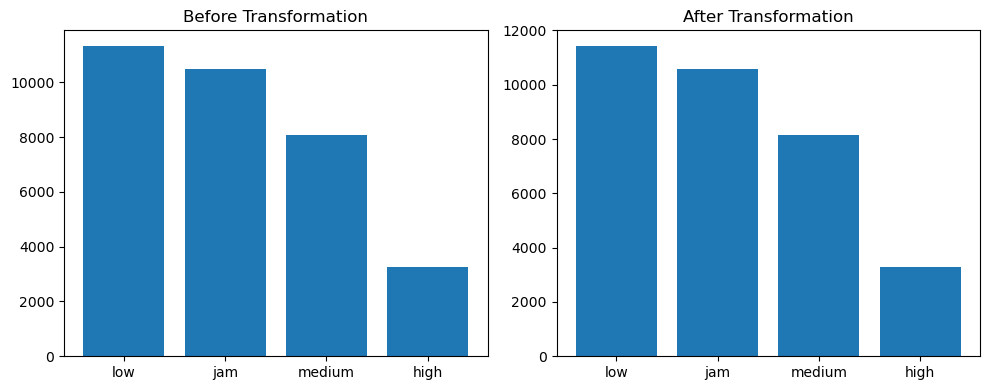

In [31]:
X_train_counts = X_train["traffic"].value_counts()
X_train_trf_counts = X_train_trf["traffic"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(X_train_counts.index, X_train_counts.values)
axes[0].set_title("Before Transformation")
axes[1].bar(X_train_trf_counts.index, X_train_trf_counts.values)
axes[1].set_title("After Transformation")

plt.tight_layout()
plt.show()

In [34]:
X_train["multi_deliveries"].value_counts()

multi_deliveries
1.0    20695
0.0    10307
2.0     1484
3.0      272
Name: count, dtype: int64

Number of missing values in 'multi_deliveries':  712
0


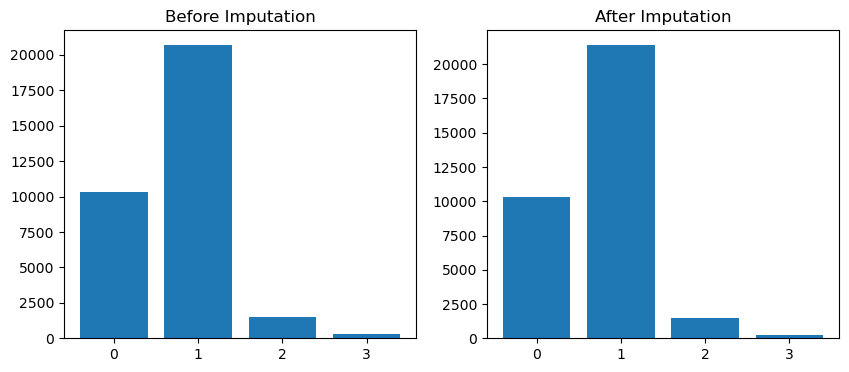

In [46]:
counts = X_train["multi_deliveries"].value_counts()

X_train_filled = X_train["multi_deliveries"].fillna(X_train["multi_deliveries"].mode()[0])
fill_counts = X_train_filled.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(counts.index, counts.values)
axes[0].set_title("Before Imputation")

axes[1].bar(fill_counts.index, fill_counts.values)
axes[1].set_title("After Imputation")

print("Number of missing values in 'multi_deliveries': ", X_train["multi_deliveries"].isnull().sum())
print(X_train_filled.isnull().sum())

In [48]:
X_train["festival"].value_counts()

festival
no     32646
yes      647
Name: count, dtype: int64

Number of missing values in 'city_type':  873
city_type
metropolitian    25054
urban             7421
semi-urban         122
Name: count, dtype: int64


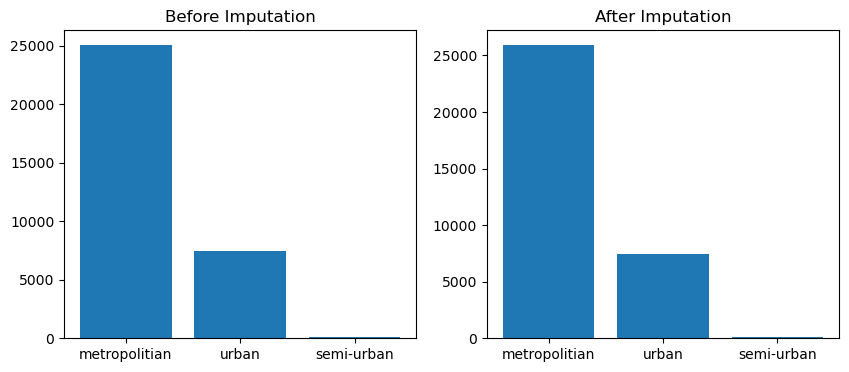

In [52]:
counts = X_train["city_type"].value_counts()

X_train_filled = X_train["city_type"].fillna(X_train["city_type"].mode()[0])
fill_counts = X_train_filled.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(counts.index, counts.values)
axes[0].set_title("Before Imputation")

axes[1].bar(fill_counts.index, fill_counts.values)
axes[1].set_title("After Imputation")

print("Number of missing values in 'city_type': ", X_train["city_type"].isnull().sum())
print(X_train["city_type"].value_counts())

Number of missing values in 'order_time_of_day':  1566
order_time_of_day
night        10103
evening      10072
morning       6298
afternoon     5431
Name: count, dtype: int64


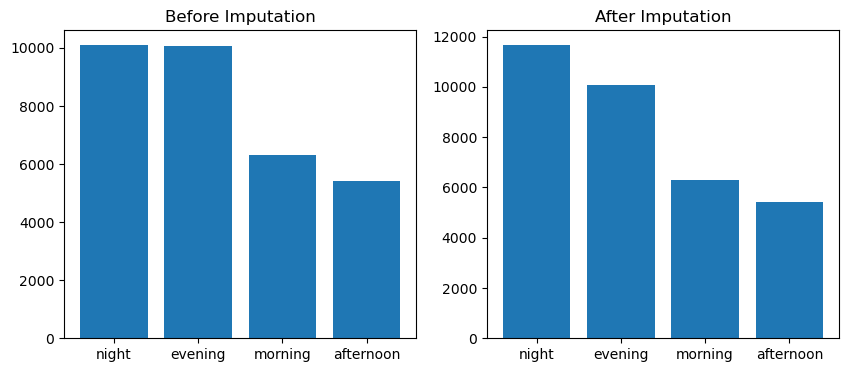

In [70]:
counts = X_train["order_time_of_day"].value_counts()

X_train_filled = X_train["order_time_of_day"].fillna(X_train["order_time_of_day"].mode()[0])
fill_counts = X_train_filled.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(counts.index, counts.values)
axes[0].set_title("Before Imputation")

axes[1].bar(fill_counts.index, fill_counts.values)
axes[1].set_title("After Imputation")

print("Number of missing values in 'order_time_of_day': ", X_train["order_time_of_day"].isnull().sum())
print(X_train["order_time_of_day"].value_counts())

Total Missing Values:  1856 Percentage of missing values:  0.055452644158948315
count    31614.000000
mean         9.454198
std          4.549978
min          0.016667
25%          5.733333
50%          9.416667
75%         13.183333
max         19.883333
Name: pickup_time, dtype: float64
20.702299060923856 19.5542675375119 19.554341316986662


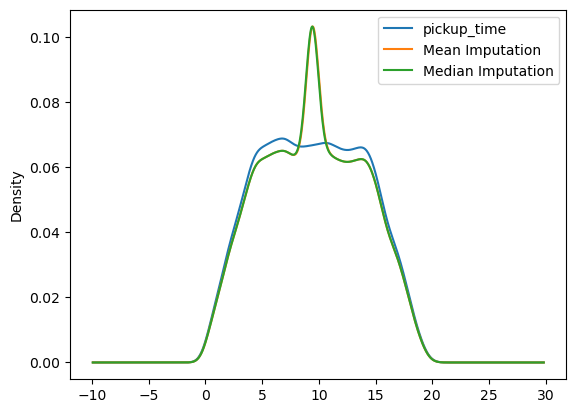

In [80]:
counts = X_train["pickup_time"].isnull().sum()
print("Total Missing Values: ", counts, "Percentage of missing values: ", counts/X_train.shape[0])

print(X_train["pickup_time"].describe())

# Simple Imputation:
X_train_mean = X_train["pickup_time"].fillna(X_train["pickup_time"].mean())
X_train_median = X_train["pickup_time"].fillna(X_train["pickup_time"].median())

X_train["pickup_time"].plot(kind="kde")
X_train_mean.plot(kind="kde", label="Mean Imputation")
X_train_median.plot(kind="kde", label="Median Imputation")

plt.legend()
print(X_train["pickup_time"].var(), X_train_mean.var(), X_train_median.var())

### Create column transformer for following experiments:

Observations:abs
- age: distribution chages probably go for KNN or iterative imputer.
- ratings: mostly fine you can go with either mean or median imputation but let's check the advance technique first.
- weather, traffic and order_time_of_day: Distribution is uniform, so mode imputation won't work but it would be either constant value imputation or random sampling imputation.
- multi_deliveries, festival and city_type: mode imputation would be appropriate.
- pickup_time: Distribution changes although there is not much reduction in variance still better use advanced techniques.

In [40]:
X = df.drop(columns=["time"])
y = df["time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(33472, 16) (8368, 16) (33472,) (8368,)


In [16]:
X_train = train_df.drop(columns=["time"])
y_train = train_df["time"]

X_test = test_df.drop(columns=["time"])
y_test = test_df["time"]

In [41]:
y_train

6489     42.0
38496    20.0
29302    20.0
29866    26.0
30878    26.0
         ... 
31620    18.0
41312    34.0
20467    15.0
932      22.0
34777    10.0
Name: time, Length: 33472, dtype: float64

In [17]:
def mode_imputation(X):

    modes_ = X.mode(dropna=True).iloc[0]
    dtypes_ = X.dtypes

    for col in X.columns:
        X[col] = X[col].fillna(modes_[col]).astype(dtypes_[col])

    return X

In [18]:
num_cols = ["age", "ratings", "pickup_time"]
mode_impute = ["multi_deliveries", "festival", "city_type"]
random_impute = ["weather", "traffic", "order_time_of_day"]

impute_categorical_random = ColumnTransformer(transformers=[
    ("mode_imputation", FunctionTransformer(mode_imputation), mode_impute),
    ("random_imputation", RandomSampleImputer(), random_impute),
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

impute_categorical_const = ColumnTransformer(transformers=[
    ("mode_imputation", FunctionTransformer(mode_imputation), mode_impute),
    ("const_imputation", SimpleImputer(strategy="constant", fill_value="missing"), random_impute),
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

impute_numerical_knn = ColumnTransformer(transformers=[
   ("knn", KNNImputer(), num_cols)
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

impute_numerical_iterative = ColumnTransformer(transformers=[
   ("iterative", IterativeImputer(), num_cols)
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

In [19]:
nom_cat = ["weather", "order_type", "vehicle_type", "festival", "city_type"]
ord_cat = ["traffic", "distance_type", "order_time_of_day"]
numerical = ["age", "ratings", "pickup_time", "distance"]

traffic_categories = ['low', 'medium', 'high', 'jam']
distance_type_categories = ['short', 'medium', 'long', 'very_long']
time_categories = ['morning', 'afternoon', "evening", 'night']

trf_categorical = ColumnTransformer(transformers=[
    ("ord_cat", OrdinalEncoder(categories=[traffic_categories, distance_type_categories, time_categories],
                              handle_unknown="use_encoded_value", unknown_value=-1), ord_cat),
    ("nom_cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nom_cat)
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

trf_categorical.set_output(transform="pandas")

trf_numerical = ColumnTransformer(transformers=[
    ("num", MinMaxScaler(), numerical)
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

trf_numerical.set_output(transform="pandas")

,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


### Experiment 2: Categorical Imputation: Mode and Random/Constant Imputation and Numerical Imputation: Iterative/KNN Imputer with Random Forest and Gradient Boosting

In [24]:
pipe = Pipeline(steps=[
    ("impute_cat", None),
    ("trf_cat", trf_categorical),
    ("impute_num", None),
    ("trf_num", trf_numerical),
    ("model", None)
])

In [25]:
param_grid = {
    "impute_cat": [impute_categorical_random, impute_categorical_const],
    "impute_num": [impute_numerical_iterative, impute_numerical_knn],
    "model": [RandomForestRegressor(), GradientBoostingRegressor()]
}

In [26]:
grid_search = GridSearchCV(pipe, param_grid=param_grid, scoring="neg_mean_absolute_error", refit=True, cv=5)

In [27]:
grid_search.fit(X_train, y_train)

print("Best Score: ", grid_search.best_score_)
print("Best Params: ", grid_search.best_params_)

Best Score:  -3.2193436936491673
Best Params:  {'impute_cat': ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('mode_imputation',
                                 FunctionTransformer(func=<function mode_imputation at 0x0000027BEDAB6160>),
                                 ['multi_deliveries', 'festival', 'city_type']),
                                ('const_imputation',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['weather', 'traffic', 'order_time_of_day'])],
                  verbose_feature_names_out=False), 'impute_num': ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('iterative', IterativeImputer(),
                                 ['age', 'ratings', 'pickup_time'])],
                  verbose_feature_names_out=False), 'model': RandomForestRegressor()}


In [64]:
y_pred = grid_search.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean absolute error: ", mae)
print("r2 score: ", r2)

Mean absolute error:  3.1980544933078394
r2 score:  0.813906835988828


In [65]:
# Log parameters:
def extract_params(grid_params):
    
    params = {"test_size": 0.2}
    
    items = list(grid_params.items())
    imputers = []
    for _, value in items[:-1]:
        imputers.extend([name for name, _, _ in value.transformers])
        params["imputers"] = str(imputers)
        
    params["encoders"] = "[ordinal, onehot]"
    params["sacler"] =  "min_max_scaler"
    params["model"] = items[-1][-1].__class__.__name__
    
    return params

print(extract_params(grid_search.cv_results_["params"][0]))
extract_params(grid_search.best_params_)    

{'test_size': 0.2, 'imputers': "['mode_imputation', 'random_imputation', 'iterative']", 'encoders': '[ordinal, onehot]', 'sacler': 'min_max_scaler', 'model': 'RandomForestRegressor'}


{'test_size': 0.2,
 'imputers': "['mode_imputation', 'const_imputation', 'iterative']",
 'encoders': '[ordinal, onehot]',
 'sacler': 'min_max_scaler',
 'model': 'RandomForestRegressor'}

In [66]:
with mlflow.start_run():
 
    for i in range(len(grid_search.cv_results_["params"])):

        with mlflow.start_run(nested=True):

            # Log parameters:
            grid_params = grid_search.cv_results_["params"][i]
            mlflow.log_params(extract_params(grid_params))
            
            # Log metrics:
            mlflow.log_metric("neg_mean_absolute_error", 
                              grid_search.cv_results_["mean_test_score"][i])
   

    # logging parameters:
    mlflow.log_params(extract_params(grid_search.best_params_))
    
    # logging metrics:
    mlflow.log_metric("mean_absolute_error", mae)
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("neg_mean_absolute_error", grid_search.best_score_)
    
    # logging model:
    # signature = mlflow.models.infer_signature(X_test, y_pred)
    # mlflow.sklearn.log_model(grid_search.best_estimator_, name='RandomForestRegressor', signature=signature)

    
    # # logging datasets:
    # mlflow.log_artifact("../data/interim/India-Food-Delivery-Time-Prediction_cleaned.csv")
    
    # # Set tags:
    # mlflow.set_tag("Author", "Priyanshu Mewal")
    # mlflow.set_tag("Description", "Food delivery prediction with random forest after imputation.")
    # mlflow.set_tag("Experiment", "Baseline Experiment with imputation")

🏃 View run honorable-donkey-975 at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1/runs/31ba4b836c65427988097ba93d1fa736
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1
🏃 View run amazing-stag-590 at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1/runs/22518986da374b6d859716c6f2874f4d
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1
🏃 View run legendary-deer-259 at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1/runs/674144692f2d4e0680555412dbb60bf8
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1
🏃 View run beautiful-trout-963 at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1/runs/5b0eba7a9d8e42c6aee44f3763e2a3c2
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/deliver

### Xgboost with numerical columns:

In [124]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 29532 entries, 2788 to 39446
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                29532 non-null  float64
 1   ratings            29532 non-null  float64
 2   weather            29532 non-null  str    
 3   traffic            29532 non-null  str    
 4   condition          29532 non-null  int64  
 5   order_type         29532 non-null  str    
 6   vehicle_type       29532 non-null  str    
 7   multi_deliveries   29532 non-null  float64
 8   festival           29532 non-null  str    
 9   city_type          29532 non-null  str    
 10  order_month        29532 non-null  int64  
 11  is_weekend         29532 non-null  int64  
 12  order_time_of_day  29532 non-null  str    
 13  pickup_time        29532 non-null  float64
 14  distance           29532 non-null  float64
 15  distance_type      29532 non-null  str    
dtypes: float64(5), int64(3), str(8)
mem

In [67]:
pipe = Pipeline(steps=[
    ("impute_cat", impute_categorical_const),
    ("trf_cat", trf_categorical),
    ("model", XGBRegressor())
])

pipe.fit(X_train, y_train)

,steps,"[('impute_cat', ...), ('trf_cat', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mode_imputation', ...), ('const_imputation', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [68]:
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mae, r2)

3.2032447806051993 0.81618735214129


In [69]:
# Evaluate pipeline using cross validation:
scores = cross_validate(pipe, X_train, y_train, cv=5, scoring=["neg_mean_absolute_error", "r2"])

In [70]:
neg_mean_absolute_error = scores["test_neg_mean_absolute_error"].mean()
mean_r2_score = scores["test_r2"].mean()

print(neg_mean_absolute_error, mean_r2_score)

-3.233334463761467 0.8125035882026742


In [71]:
with mlflow.start_run(run_name="Xgboost"):
    
    parameters = {
        "test_size": 0.2,
        'imputers': "['mode_imputation', 'const_imputation']",
        "encoders": '[ordinal, onehot]',
        "model": XGBRegressor().__class__.__name__
    }

    # logging parameters:
    mlflow.log_params(parameters)
    
    # logging metrics:
    mlflow.log_metric("mean_absolute_error", mae)
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("neg_mean_absolute_error", neg_mean_absolute_error)
    mlflow.log_metric("mean_r2_score", mean_r2_score)
    
    # logging model:
    # signature = mlflow.models.infer_signature(X_test, y_pred)
    # mlflow.sklearn.log_model(pipe, name="'XGBRegressor'", signature=signature)

    
    # logging datasets:
    # mlflow.log_artifact("../data/interim/India-Food-Delivery-Time-Prediction_cleaned.csv")
    
    # Set tags:
    # mlflow.set_tag("Author", "Priyanshu Mewal")
    # mlflow.set_tag("Description", "Food delivery prediction using XGBRegressor.")
    # mlflow.set_tag("Experiment", "Baseline Experiment")

🏃 View run Xgboost at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1/runs/2b7dc2dbbf284274a779615bd06d1f0c
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/1


### Experiment 3: Hyperparameter tunning over Iterative Imputation:

In [53]:
mlflow.set_tracking_uri("https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow")

dagshub.init(repo_owner='PriyanshuMewal', repo_name='delivery-time-prediction', mlflow=True)

mlflow.set_experiment("Experiment 2: Best Imputer")

Initialized MLflow to track repo "PriyanshuMewal/delivery-time-prediction"

Repository PriyanshuMewal/delivery-time-prediction initialized!

2026/02/17 16:13:10 INFO mlflow.tracking.fluent: Experiment with name 'Experiment 2: Best Imputer' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/d98a0da0ef4d4f90b2f898345dc89b52', creation_time=1771324990684, experiment_id='2', last_update_time=1771324990684, lifecycle_stage='active', name='Experiment 2: Best Imputer', tags={}>

In [26]:
preprocess_categorical = Pipeline(steps=[
    ("impute_cat", impute_categorical_const),
    ("trf_cat", trf_categorical)
])

X_train_cat_trf = preprocess_categorical.fit_transform(X_train)
X_train_cat_trf.isnull().sum()

traffic                             0
distance_type                       0
order_time_of_day                   0
weather_fog                         0
weather_missing                     0
weather_sandstorms                  0
weather_stormy                      0
weather_sunny                       0
weather_windy                       0
order_type_drinks                   0
order_type_meal                     0
order_type_snack                    0
vehicle_type_electric_scooter       0
vehicle_type_motorcycle             0
vehicle_type_scooter                0
festival_yes                        0
city_type_semi-urban                0
city_type_urban                     0
multi_deliveries                    0
age                              1355
ratings                          1395
condition                           0
order_month                         0
is_weekend                          0
pickup_time                      1829
distance                            0
dtype: int64

In [32]:
lgb_estimator = LGBMRegressor(
    n_estimators=300, max_depth=-1,
    learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42
)

# Define the objective function for Optuna
def objective(trial):

    max_iter = trial.suggest_int("max_iter", 10, 20)
    
    impute_numerical = ColumnTransformer(
        transformers=[("iterative", 
                       IterativeImputer(estimator=lgb_estimator, 
                                        max_iter=max_iter), num_cols)], 
        remainder="passthrough", n_jobs=-1, 
        verbose_feature_names_out=False
    )

    impute_numerical.set_output(transform="pandas")  
    
    remaining_pipe = Pipeline(steps=[
    ("impute_num", impute_numerical),
    ("model_training", RandomForestRegressor())
    ])

    # Perform cross-validation and return the mean accuracy
    scores = cross_val_score(remaining_pipe, X_train_cat_trf, y_train, cv=3, scoring="neg_mean_absolute_error")

    mae = scores.mean()
    
    return mae

In [33]:
# Create a study and optimize it using CmaEsSampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=16)

[I 2026-02-17 15:06:49,175] A new study created in memory with name: no-name-68112495-0b65-4667-805a-7f4295bbbb76


step 1 - done


[I 2026-02-17 15:08:43,870] Trial 0 finished with value: -3.2402915094643707 and parameters: {'max_iter': 10}. Best is trial 0 with value: -3.2402915094643707.


Step 2- done
step 1 - done


[I 2026-02-17 15:10:39,282] Trial 1 finished with value: -3.2349611059184498 and parameters: {'max_iter': 14}. Best is trial 1 with value: -3.2349611059184498.


Step 2- done
step 1 - done


[I 2026-02-17 15:13:13,467] Trial 2 finished with value: -3.2433997182601977 and parameters: {'max_iter': 20}. Best is trial 1 with value: -3.2349611059184498.


Step 2- done
step 1 - done


[I 2026-02-17 15:14:57,525] Trial 3 finished with value: -3.238554454356956 and parameters: {'max_iter': 11}. Best is trial 1 with value: -3.2349611059184498.


Step 2- done
step 1 - done


[I 2026-02-17 15:16:46,241] Trial 4 finished with value: -3.235259996924299 and parameters: {'max_iter': 11}. Best is trial 1 with value: -3.2349611059184498.


Step 2- done
step 1 - done


[I 2026-02-17 15:18:59,394] Trial 5 finished with value: -3.242003638327356 and parameters: {'max_iter': 16}. Best is trial 1 with value: -3.2349611059184498.


Step 2- done
step 1 - done


[I 2026-02-17 15:21:00,086] Trial 6 finished with value: -3.233028840074932 and parameters: {'max_iter': 15}. Best is trial 6 with value: -3.233028840074932.


Step 2- done
step 1 - done


[I 2026-02-17 15:22:54,053] Trial 7 finished with value: -3.2333290968686494 and parameters: {'max_iter': 13}. Best is trial 6 with value: -3.233028840074932.


Step 2- done
step 1 - done


[I 2026-02-17 15:25:17,027] Trial 8 finished with value: -3.2297941622090196 and parameters: {'max_iter': 15}. Best is trial 8 with value: -3.2297941622090196.


Step 2- done
step 1 - done


[I 2026-02-17 15:27:21,037] Trial 9 finished with value: -3.2453477086844096 and parameters: {'max_iter': 10}. Best is trial 8 with value: -3.2297941622090196.


Step 2- done
step 1 - done


[I 2026-02-17 15:29:30,470] Trial 10 finished with value: -3.2412279693005543 and parameters: {'max_iter': 18}. Best is trial 8 with value: -3.2297941622090196.


Step 2- done
step 1 - done


[I 2026-02-17 15:31:29,719] Trial 11 finished with value: -3.2359874145571936 and parameters: {'max_iter': 16}. Best is trial 8 with value: -3.2297941622090196.


Step 2- done
step 1 - done


[I 2026-02-17 15:33:34,365] Trial 12 finished with value: -3.2328505579270757 and parameters: {'max_iter': 15}. Best is trial 8 with value: -3.2297941622090196.


Step 2- done
step 1 - done


[I 2026-02-17 15:35:47,658] Trial 13 finished with value: -3.2393835485613978 and parameters: {'max_iter': 18}. Best is trial 8 with value: -3.2297941622090196.


Step 2- done
step 1 - done


[I 2026-02-17 15:37:42,353] Trial 14 finished with value: -3.2362386563871213 and parameters: {'max_iter': 13}. Best is trial 8 with value: -3.2297941622090196.


Step 2- done
step 1 - done


[I 2026-02-17 15:39:55,565] Trial 15 finished with value: -3.2374795023778895 and parameters: {'max_iter': 17}. Best is trial 8 with value: -3.2297941622090196.


Step 2- done


In [49]:
def extract_params(params):

    parameters = {
        "test_size": 0.2,
        'imputers': "['mode_imputation', 'const_imputation', 'iterative']",
        "encoders": '[ordinal, onehot]',
        'sacler': 'min_max_scaler', 
        'model': 'RandomForestRegressor'
    }

    parameters.update(params)

    return parameters

extract_params(study.best_params)

{'test_size': 0.2,
 'imputers': "['mode_imputation', 'const_imputation', 'iterative']",
 'encoders': '[ordinal, onehot]',
 'sacler': 'min_max_scaler',
 'model': 'RandomForestRegressor',
 'max_iter': 15}

In [60]:
with mlflow.start_run():
    
    for trial in study.trials:
    
        with mlflow.start_run(nested=True):
    
            mlflow.log_params(extract_params(trial.params))
    
            mlflow.log_metric("neg_mean_absolute_error", trial.value)
     

    # logging parameters:
    mlflow.log_params(extract_params(study.best_params))
    
    # logging metrics:
    mlflow.log_metric("neg_mean_absolute_error", study.best_value)        
    
    
    # logging datasets:
    # mlflow.log_artifact("../data/interim/reddit_cleaned.csv")
    
    # Set tags:
    # Set tags:
    # mlflow.set_tag("Author", "Priyanshu Mewal")
    # mlflow.set_tag("Description", "Food delivery prediction using Iterative Imputer with max_iter=15.")
    # mlflow.set_tag("Experiment", "HP over iterative imputer")

🏃 View run fearless-cod-743 at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/2/runs/85be190153864a0dbb92d8fd3b55defc
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/2
🏃 View run bustling-turtle-534 at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/2/runs/484a0ace244e486faa195e8ea8f53800
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/2
🏃 View run intrigued-moth-444 at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/2/runs/e37d1c86f1214afb81d9143a6acee77c
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/2
🏃 View run classy-cat-212 at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/2/runs/c6a0c3c7500a414ca81c7970bab36069
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time

### Final Pipeline: Mode, Constant and Iterative Imputations:

In [20]:
lgb_estimator = LGBMRegressor(
    n_estimators=300, max_depth=-1,
    learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42
)

impute_numerical_iterative = ColumnTransformer(transformers=[
   ("iterative", IterativeImputer(estimator=lgb_estimator, max_iter=15), num_cols)
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

final_preprocessing = Pipeline(steps=[
    ("impute_cat", impute_categorical_const),
    ("trf_cat", trf_categorical),
    ("impute_num", impute_numerical_iterative),
    ("trf_num", trf_numerical),
])

processed_X_train = final_preprocessing.fit_transform(X_train)
processed_X_test = final_preprocessing.transform(X_test)

In [11]:
scaler = StandardScaler()

y_train_scaled = pd.Series(scaler.fit_transform(y_train.values.reshape(y_train.shape[0], 1)).values.ravel(), 
                           index=y_train.index, name=y_train.name)
y_test_scaled = pd.Series(scaler.transform(y_test.values.reshape(y_test.shape[0], 1)).values.ravel(), 
                           index=y_test.index, name=y_test.name)

In [12]:
processed_X_train["time"] = y_train_scaled
processed_X_test["time"] = y_test_scaled

processed_X_train.shape, processed_X_test.shape

((33504, 27), (8368, 27))

In [14]:
processed_X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 8368 entries, 0 to 8367
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            8368 non-null   float64
 1   ratings                        8368 non-null   float64
 2   pickup_time                    8368 non-null   float64
 3   distance                       8368 non-null   float64
 4   traffic                        8368 non-null   float64
 5   distance_type                  8368 non-null   float64
 6   order_time_of_day              8368 non-null   float64
 7   weather_fog                    8368 non-null   float64
 8   weather_missing                8368 non-null   float64
 9   weather_sandstorms             8368 non-null   float64
 10  weather_stormy                 8368 non-null   float64
 11  weather_sunny                  8368 non-null   float64
 12  weather_windy                  8368 non-null   float64
 13 

In [29]:
import pickle

processed_X_train.to_csv("../data/processed/with_imputation/train_df.csv", index=False)
processed_X_test.to_csv("../data/processed/with_imputation/test_df.csv", index=False)

with open("../data/processed/with_imputation/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [50]:
processed_X_test.isnull().sum()

age                              0
ratings                          0
pickup_time                      0
distance                         0
traffic                          0
distance_type                    0
order_time_of_day                0
weather_fog                      0
weather_missing                  0
weather_sandstorms               0
weather_stormy                   0
weather_sunny                    0
weather_windy                    0
order_type_drinks                0
order_type_meal                  0
order_type_snack                 0
vehicle_type_electric_scooter    0
vehicle_type_motorcycle          0
vehicle_type_scooter             0
festival_yes                     0
city_type_semi-urban             0
city_type_urban                  0
multi_deliveries                 0
condition                        0
order_month                      0
is_weekend                       0
time                             0
dtype: int64